# SaaSFlow · Modelo predictivo de ingresos recurrentes
**Evaluación 2**  
Regresión lineal para estimar el ingreso mensual recurrente (MRR) del próximo trimestre.

### Contexto y objetivo
SaaSFlow necesita proyectar sus ingresos y organizar el trabajo de Customer Success, el equipo que acompaña a los clientes para que aprovechen el servicio y mantengan su relación con la empresa. Construiremos un modelo que estime el MRR a partir de las características de las empresas, su actividad y su comportamiento comercial.

La variable objetivo es **`mrr_proximo_trimestre`**, expresada en **USD mensuales por cliente**. No representa la suma de los tres meses del trimestre. `id_cliente` se utiliza como identificador y se excluye del modelo.

### Recorrido del notebook
| Fase | Qué haremos | Resultado esperado |
| :--- | :--- | :--- |
| 1. Diagnóstico y calidad | Revisar nulos, tipos, categorías y distribuciones. | Identificar los problemas que debemos tratar. |
| 2. Preparación de datos | Definir imputación, tratamiento de extremos, antigüedad, codificación y escalado. | Un preprocesador integrado al modelo. |
| 3. Construcción del modelo | Separar entrenamiento y prueba; entrenar una regresión lineal. | Un modelo ajustado solo con entrenamiento. |
| 4. Evaluación e interpretación | Calcular R² y MAE y relacionarlos con el negocio. | Resultados y recomendaciones con sus limitaciones. |

---
## Fase 1 · Diagnóstico y calidad de datos
Primero revisaremos el estado inicial del dataset: cuántos registros contiene, dónde faltan datos y cómo se distribuyen las variables. Este diagnóstico orienta las decisiones de preparación; los parámetros del preprocesamiento se aprenderán más adelante, únicamente con entrenamiento.

### 1.1 Carga de datos y librerías

In [1]:
from pathlib import Path
from IPython.display import display, Markdown

import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, FunctionTransformer, StandardScaler

from sklearn.base import BaseEstimator, TransformerMixin

sb.set_theme(style="whitegrid", context="notebook", palette="muted")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False,
                     "axes.spines.right": False})

In [2]:
dataset_path = Path("clientes_mrr_dataset.csv")
dataset_url = (
    "https://raw.githubusercontent.com/benjaminqq-12/"
    "Inteligencia-Artificial-2026-2/refs/heads/main/"
    "E2-Regresion/clientes_mrr_dataset.csv"
)

# Reutilizar el CSV evita descargas duplicadas al volver a ejecutar el notebook.
if not dataset_path.exists():
    pd.read_csv(dataset_url).to_csv(dataset_path, index=False)

data = pd.read_csv(dataset_path)
print(f"Dataset: {data.shape[0]:,} clientes y {data.shape[1]} variables.")
display(data.head())

Dataset: 30,000 clientes y 11 variables.


,id_cliente,fecha_registro,sector_empresa,tamano_empresa,tickets_soporte,promedio_sesiones_mes,satisfaccion_nps,duracion_contrato,gasto_mkt_asociado,pago_puntual,mrr_proximo_trimestre
0,CLI-0001,2025-09-14 00:24:49.009633632,Finanzas,Mediana,3.0,34.350838,7.0,Mensual,3932.341944,Si,706.16
1,CLI-0002,2024-02-12 19:17:24.874829152,Tecnologia,Mediana,NaN,28.685569,8.0,Mensual,2547.833298,No,555.95
2,CLI-0003,2021-02-03 13:56:48.713623787,Tecnologia,Pequeña,5.0,50.027033,7.0,2 Años,3203.232664,Si,755.53
3,CLI-0004,2021-08-19 03:21:50.803693456,Educacion,Pequeña,0.0,NaN,9.0,Anual,603.209270,No,364.94
4,CLI-0005,2021-09-26 05:21:16.482549416,Educacion,Grande,3.0,NaN,8.0,Anual,864.788600,Si,1611.93


### 1.2 Valores faltantes y duplicados
Calculamos el porcentaje de nulos **para cada variable**, incluidas las que no tienen datos faltantes. El porcentaje global corresponde a celdas vacías, no a clientes que debamos eliminar.

In [3]:
null_summary = pd.DataFrame({
    "Nulos": data.isna().sum(),
    "Porcentaje (%)": data.isna().mean().mul(100).round(2)
})
display(null_summary)

total_nulls = int(data.isna().sum().sum())
print(f"Total de valores nulos: {total_nulls:,}")
print(f"Porcentaje de celdas con nulos: {100 * total_nulls / data.size:.2f}%")
print(f"Filas duplicadas: {data.duplicated().sum()}")
print(f"Identificadores repetidos: {data['id_cliente'].duplicated().sum()}")

,Nulos,Porcentaje (%)
id_cliente,0,0.00
fecha_registro,0,0.00
sector_empresa,0,0.00
tamano_empresa,0,0.00
tickets_soporte,2464,8.21
promedio_sesiones_mes,1545,5.15
satisfaccion_nps,3597,11.99
duracion_contrato,0,0.00
gasto_mkt_asociado,0,0.00
pago_puntual,0,0.00


Total de valores nulos: 7,606
Porcentaje de celdas con nulos: 2.30%
Filas duplicadas: 0
Identificadores repetidos: 0


**Lectura del diagnóstico.** Los faltantes se concentran en `tickets_soporte` (8,21%), `promedio_sesiones_mes` (5,15%) y `satisfaccion_nps` (11,99%). Conservaremos estos clientes y completaremos sus valores mediante imputación. El archivo revisado no contiene filas duplicadas ni identificadores repetidos.

### 1.3 Tipos de datos y categorías
La fecha de registro llega como texto y debe convertirse a fecha. Las demás variables categóricas se mantienen como texto durante el diagnóstico; su codificación se define en la fase 2.

In [4]:
print("Tipos de datos iniciales:")
data.info()

data["fecha_registro"] = pd.to_datetime(data["fecha_registro"], errors="raise")
print("\nTipo de fecha_registro después de convertir:", data["fecha_registro"].dtype)
print("Rango de fechas:", data["fecha_registro"].min().date(),
      "a", data["fecha_registro"].max().date())

Tipos de datos iniciales:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_cliente             30000 non-null  object 
 1   fecha_registro         30000 non-null  object 
 2   sector_empresa         30000 non-null  object 
 3   tamano_empresa         30000 non-null  object 
 4   tickets_soporte        27536 non-null  float64
 5   promedio_sesiones_mes  28455 non-null  float64
 6   satisfaccion_nps       26403 non-null  float64
 7   duracion_contrato      30000 non-null  object 
 8   gasto_mkt_asociado     30000 non-null  float64
 9   pago_puntual           30000 non-null  object 
 10  mrr_proximo_trimestre  30000 non-null  float64
dtypes: float64(5), object(6)
memory usage: 2.5+ MB

Tipo de fecha_registro después de convertir: datetime64[ns]
Rango de fechas: 2021-01-01 a 2025-12-31


In [5]:
print('Valores únicos en sector_empresa:', data['sector_empresa'].unique())
print('Valores únicos en tamano_empresa:', data['tamano_empresa'].unique())
print('Valores únicos en duracion_contrato:', data['duracion_contrato'].unique())
print('Valores únicos en pago_puntual:', data['pago_puntual'].unique())

Valores únicos en sector_empresa: ['Finanzas' 'Tecnologia' 'Educacion' 'Salud' 'Retail']
Valores únicos en tamano_empresa: ['Mediana' 'Pequeña' 'Grande']
Valores únicos en duracion_contrato: ['Mensual' '2 Años' 'Anual']
Valores únicos en pago_puntual: ['Si' 'No']


### 1.4 Distribuciones, asimetría y valores atípicos
Usaremos estadísticas descriptivas, asimetría, diagramas de caja e histogramas. Un valor extremo no necesariamente es un error: puede representar un cliente con un comportamiento poco habitual.

In [6]:
numerical_cols = [
    "tickets_soporte", "promedio_sesiones_mes", "satisfaccion_nps",
    "gasto_mkt_asociado", "mrr_proximo_trimestre"
]

display(data[numerical_cols].describe().round(2))
skewness = data[numerical_cols].skew()
display(skewness.round(3).to_frame("Asimetría"))

variable_labels = {
    "tickets_soporte": "Tickets de soporte",
    "promedio_sesiones_mes": "Sesiones mensuales",
    "satisfaccion_nps": "Satisfacción",
    "gasto_mkt_asociado": "Gasto de marketing (USD)",
    "mrr_proximo_trimestre": "MRR futuro (USD/mes)"
}

,tickets_soporte,promedio_sesiones_mes,satisfaccion_nps,gasto_mkt_asociado,mrr_proximo_trimestre
count,27536.00,28455.00,26403.00,30000.00,30000.00
mean,3.01,50.13,5.91,2551.09,710.93
std,1.73,45.06,2.31,1416.11,337.69
min,0.00,5.00,1.00,100.36,50.00
25%,2.00,18.09,4.00,1330.53,458.98
50%,3.00,36.23,6.00,2541.07,642.60
75%,4.00,67.45,8.00,3785.67,896.70
max,12.00,430.70,10.00,4999.95,3200.04


,Asimetría
tickets_soporte,0.569
promedio_sesiones_mes,1.972
satisfaccion_nps,-0.417
gasto_mkt_asociado,0.004
mrr_proximo_trimestre,1.055


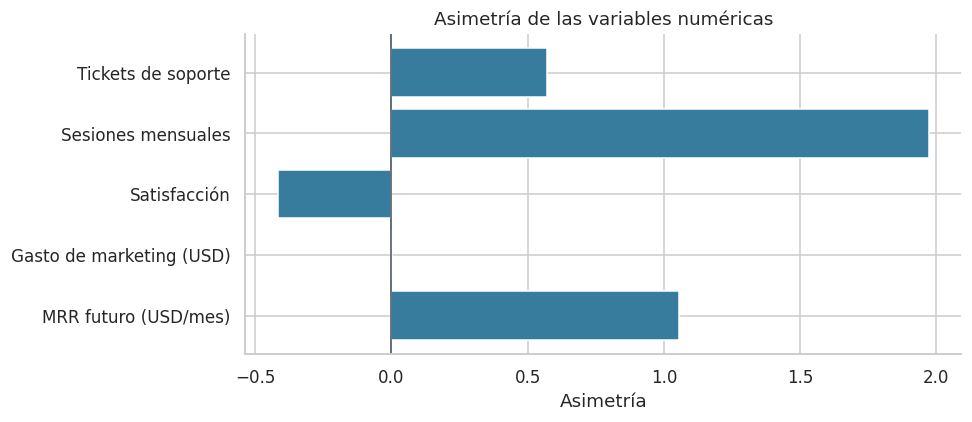

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh([variable_labels[c] for c in skewness.index], skewness.values, color="#387C9D")
ax.axvline(0, color="#46505A", linewidth=1)
ax.set(title="Asimetría de las variables numéricas", xlabel="Asimetría")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

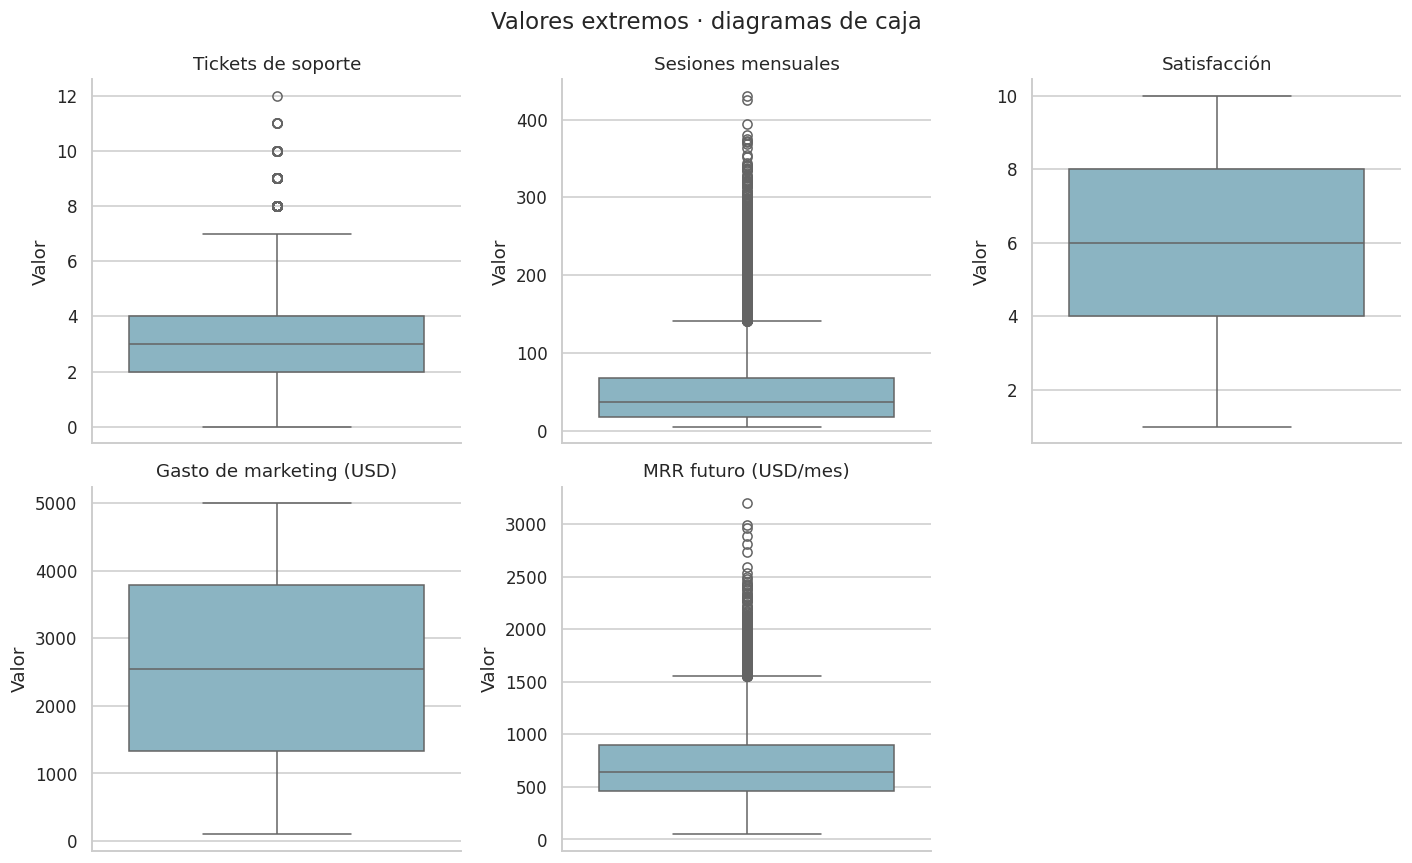

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for ax, col in zip(axes.flat, numerical_cols):
    sb.boxplot(y=data[col], ax=ax, color="#82B9CB")
    ax.set(title=variable_labels[col], ylabel="Valor")
axes.flat[-1].set_visible(False)
fig.suptitle("Valores extremos · diagramas de caja", fontsize=15)
plt.tight_layout()
plt.show()

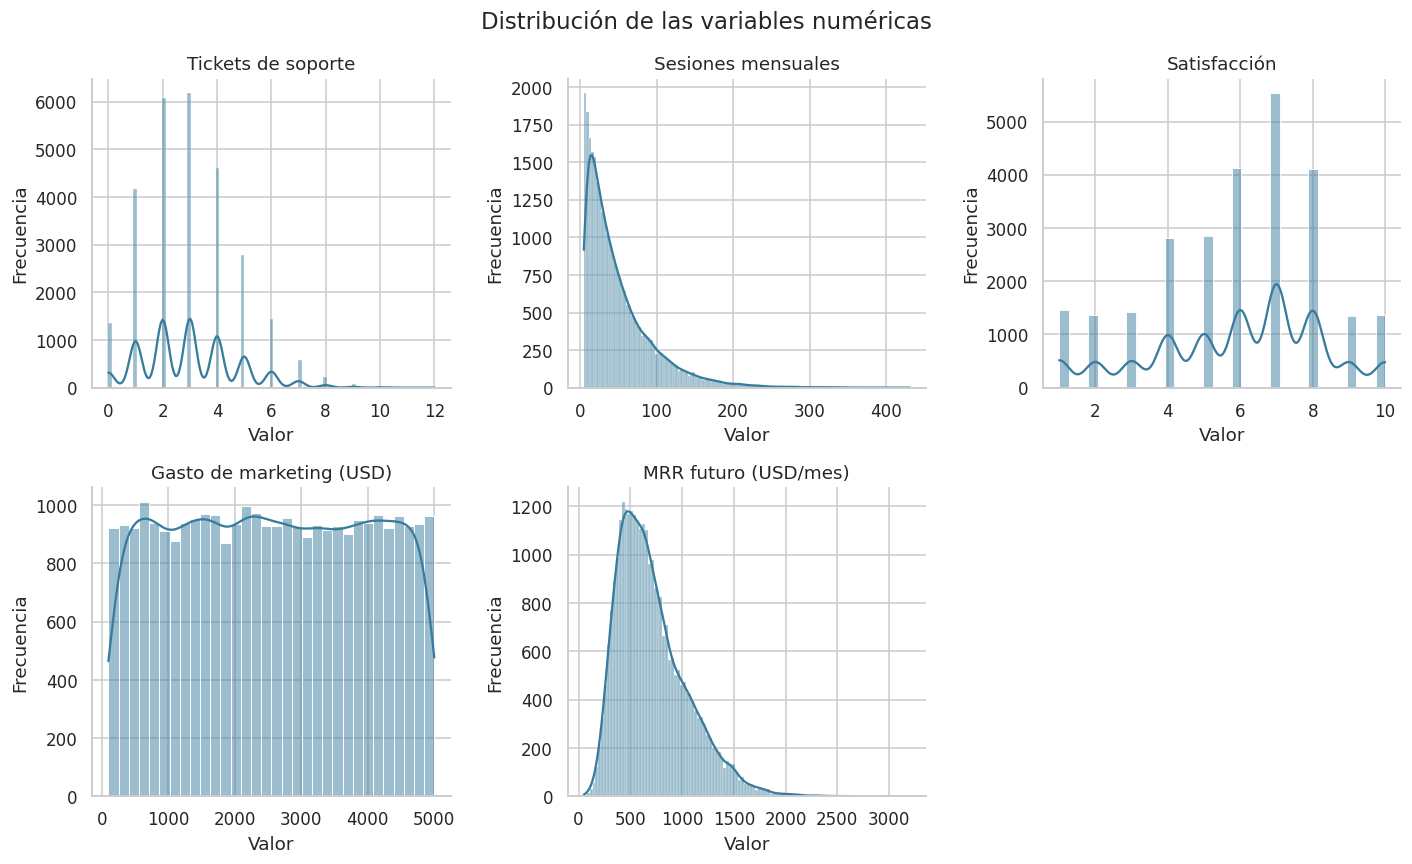

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for ax, col in zip(axes.flat, numerical_cols):
    sb.histplot(data[col].dropna(), kde=True, ax=ax, color="#387C9D")
    ax.set(title=variable_labels[col], xlabel="Valor", ylabel="Frecuencia")
axes.flat[-1].set_visible(False)
fig.suptitle("Distribución de las variables numéricas", fontsize=15)
plt.tight_layout()
plt.show()

**Conclusión de la fase 1.** Las sesiones mensuales presentan una asimetría positiva marcada (aproximadamente 1,97), mientras que el gasto de marketing es casi simétrico. El MRR también tiene una cola hacia valores altos. Por eso usamos una imputación resistente a extremos para las sesiones y mantenemos el MRR original para evaluar errores en dólares reales.

---
## Fase 2 · Limpieza y tratamiento de datos
Definiremos las transformaciones y las reuniremos en un `ColumnTransformer`. En esta fase solo se configura el preprocesador: sus imputadores, límites de valores extremos y escaladores se ajustan al entrenar el pipeline en la fase 3.

### 2.1 Decisiones de preparación
| Variables | Tratamiento | Justificación |
| :--- | :--- | :--- |
| Sesiones mensuales | Mediana → winsorización → estandarización | La mediana es menos sensible a los valores muy altos observados. |
| Tickets y satisfacción | Moda → winsorización → estandarización | La moda completa los faltantes con un valor discreto observado y frecuente. Es una decisión sencilla, no una garantía de que sea la mejor imputación. |
| Gasto de marketing | Estandarización | No tiene nulos; su distribución es aproximadamente simétrica. |
| Fecha de registro | Antigüedad en días → estandarización | Convierte la fecha en una cantidad numérica interpretable. |
| Tamaño de empresa | Codificación ordinal: 0, 1 y 2 | Conserva el orden Pequeña → Mediana → Grande. |
| Duración del contrato | Codificación ordinal: 0, 1 y 2 | Representa Mensual → Anual → 2 Años; los códigos no son meses. |
| Pago puntual | Codificación binaria: No = 0, Si = 1 | Representa las dos respuestas posibles. |
| Sector | One-Hot Encoding | Representa categorías sin imponerles un orden. |

`SimpleImputer` calcula la mediana o la moda de cada columna durante `fit` y usa ese valor para sustituir sus nulos. La imputación no recupera el valor verdadero y puede concentrar observaciones en el valor elegido.

La **winsorización** limita valores a los percentiles 5 y 95; no elimina filas. Puede reducir información de extremos válidos. `StandardScaler` resta la media y divide por la desviación estándar para expresar las variables en una escala común.

### 2.2 Tratamiento de valores extremos
Guardamos los percentiles calculados con entrenamiento y reutilizamos esos mismos límites en prueba y en clientes nuevos. Así, el resultado no depende del lote que se está prediciendo.

In [10]:
class Winsorizer(BaseEstimator, TransformerMixin):
    """Limita valores usando percentiles aprendidos en entrenamiento."""

    def __init__(self, limits=(0.05, 0.05)):
        self.limits = limits

    def fit(self, X, y=None):
        self.columns_ = X.columns if isinstance(X, pd.DataFrame) else np.arange(X.shape[1])
        X_df = pd.DataFrame(X, columns=self.columns_).astype(float)
        self.lower_bounds_ = X_df.quantile(self.limits[0])
        self.upper_bounds_ = X_df.quantile(1 - self.limits[1])
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X, columns=self.columns_).astype(float)
        # No recalcular percentiles con los datos de prueba.
        return X_df.clip(lower=self.lower_bounds_, upper=self.upper_bounds_, axis=1)

    def get_feature_names_out(self, input_features=None):
        return np.asarray(self.columns_ if input_features is None else input_features)

### 2.3 Ingeniería de características: antigüedad
Calculamos los días transcurridos desde el registro hasta una **fecha de referencia fija: 1 de octubre de 2026**, elegida para este ejercicio. No se utiliza el máximo de cada lote: un mismo cliente debe conservar su antigüedad al predecirlo solo o junto a otros. Para una aplicación real, habría que confirmar la fecha de corte de los datos y que las variables existan antes del período que se desea pronosticar.

In [11]:
FECHA_REFERENCIA = pd.Timestamp("2026-10-01")

def calculate_seniority_days(X):
    """Calcula antigüedad sin modificar los datos recibidos."""
    fechas = pd.to_datetime(X["fecha_registro"])
    return (FECHA_REFERENCIA - fechas).dt.days.to_numpy().reshape(-1, 1)

### 2.4 Pipelines de variables numéricas
Cada grupo recibe únicamente las transformaciones definidas para él. Aunque tickets y satisfacción comparten la misma configuración, cada columna aprende sus propios valores al ajustar el `ColumnTransformer`.

In [12]:
numeric_pipeline_gasto_mkt = Pipeline(steps=[
    ("scaler", StandardScaler())
])

numeric_pipeline_mode_impute_winsorize_scale = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("winsorizer", Winsorizer()),
    ("scaler", StandardScaler())
])

numeric_pipeline_median_impute_winsorize_scale = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("winsorizer", Winsorizer()),
    ("scaler", StandardScaler())
])

date_pipeline = Pipeline(steps=[
    ('seniority_calculator', FunctionTransformer(
        calculate_seniority_days,
        validate=False,
        feature_names_out=lambda _, names: ['antiguedad_dias']
    )),
    ('scaler', StandardScaler())
])

### 2.5 Pipelines de variables categóricas
En sector se deja una categoría como referencia (`drop="first"`) para evitar columnas redundantes junto al intercepto. En tamaño y contrato, los códigos 0, 1 y 2 suponen saltos iguales dentro de la regresión: es una simplificación del modelo.

In [13]:
categorical_pipeline_tamano_empresa = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinal_encoder", OrdinalEncoder(
        categories=[['Pequeña', 'Mediana', 'Grande']],
        handle_unknown="use_encoded_value",
        unknown_value=-1
    ))
])

categorical_pipeline_duracion_contrato = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinal_encoder", OrdinalEncoder(
        categories=[['Mensual', 'Anual', '2 Años']],
        handle_unknown="use_encoded_value",
        unknown_value=-1
    ))
])

categorical_pipeline_pago_puntual = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinal_encoder", OrdinalEncoder(categories=[['No', 'Si']], handle_unknown='use_encoded_value', unknown_value=-1))
])

categorical_pipeline_sector_empresa = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot_encoder", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False))
])

### 2.6 Integración del preprocesamiento
El `ColumnTransformer` aplica cada pipeline a sus columnas y reúne los resultados. Se excluyen el identificador y la variable objetivo al preparar `X` en la siguiente fase.

In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        ('tickets_pipe', numeric_pipeline_mode_impute_winsorize_scale, ['tickets_soporte']),
        ('promedio_sesiones_pipe', numeric_pipeline_median_impute_winsorize_scale, ['promedio_sesiones_mes']),
        ('satisfaccion_pipe', numeric_pipeline_mode_impute_winsorize_scale, ['satisfaccion_nps']),
        ('gasto_mkt_pipe', numeric_pipeline_gasto_mkt, ['gasto_mkt_asociado']),
        ('fecha_pipe', date_pipeline, ['fecha_registro']),
        ('tamano_pipe', categorical_pipeline_tamano_empresa, ['tamano_empresa']),
        ('duracion_pipe', categorical_pipeline_duracion_contrato, ['duracion_contrato']),
        ('pago_pipe', categorical_pipeline_pago_puntual, ['pago_puntual']),
        ('sector_pipe', categorical_pipeline_sector_empresa, ['sector_empresa'])
    ],
    remainder='drop'
)

---
## Fase 3 · Construcción del modelo
Separaremos el 80% de los clientes para entrenamiento y el 20% para prueba. Después entrenaremos la regresión lineal junto con el preprocesador, sin ajustar transformaciones con el conjunto de prueba.

### 3.1 División de entrenamiento y prueba
Usamos `random_state=42` para reproducir la misma separación. El identificador no aporta una característica del cliente y el ingreso futuro debe quedar únicamente en `y`.

In [15]:
target = "mrr_proximo_trimestre"

X = data.drop(columns=[target, 'id_cliente'])
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Clientes de entrenamiento: {len(X_train):,}")
print(f"Clientes de prueba: {len(X_test):,}")

Clientes de entrenamiento: 24,000
Clientes de prueba: 6,000


### 3.2 Entrenamiento de la regresión lineal
Una única llamada a `fit` ajusta primero el preprocesamiento y luego la regresión. Al llamar a `predict`, se reutilizan las transformaciones aprendidas.

In [16]:
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

model.fit(X_train, y_train)
print("Pipeline de regresión lineal entrenado.")

Pipeline de regresión lineal entrenado.


---
## Fase 4 · Evaluación e interpretación de métricas
Mediremos el desempeño con clientes del conjunto de prueba, que no se usaron para entrenar. Reportaremos R² y MAE y explicaremos qué significan para la planificación de ingresos de SaaSFlow.

### 4.1 Resultados sobre el conjunto de prueba

In [17]:
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f'R2 Score en el conjunto de prueba: {r2:.4f}')
print(f'Mean Absolute Error (MAE) en el conjunto de prueba: {mae:.2f} USD')

R2 Score en el conjunto de prueba: 0.8983
Mean Absolute Error (MAE) en el conjunto de prueba: 74.44 USD


In [18]:
display(Markdown(
    f"**R² = {r2:.4f}.** El modelo explica aproximadamente el **{r2 * 100:.2f}%** "
    "de la variación del MRR en este conjunto de prueba. No significa que acierte "
    "ese porcentaje de clientes ni asegura el mismo desempeño en otro trimestre.\n\n"
    f"**MAE = {mae:.2f} USD.** Las predicciones se alejan del ingreso real, en promedio, "
    f"**{mae:.2f} dólares de MRR mensual por cliente**. Es el promedio de los errores "
    "absolutos: no es un error máximo ni un intervalo de más o menos esa cantidad.\n\n"
    "**Uso financiero.** Estas estimaciones pueden apoyar la planificación, pero para "
    "decidir si el error es aceptable hay que considerar los ingresos de los clientes "
    "y el costo de las decisiones. El MAE individual tampoco es, por sí solo, el "
    "error de la suma de ingresos de toda la cartera."
))

**R² = 0.8983.** El modelo explica aproximadamente el **89.83%** de la variación del MRR en este conjunto de prueba. No significa que acierte ese porcentaje de clientes ni asegura el mismo desempeño en otro trimestre.

**MAE = 74.44 USD.** Las predicciones se alejan del ingreso real, en promedio, **74.44 dólares de MRR mensual por cliente**. Es el promedio de los errores absolutos: no es un error máximo ni un intervalo de más o menos esa cantidad.

**Uso financiero.** Estas estimaciones pueden apoyar la planificación, pero para decidir si el error es aceptable hay que considerar los ingresos de los clientes y el costo de las decisiones. El MAE individual tampoco es, por sí solo, el error de la suma de ingresos de toda la cartera.

### 4.2 Coeficientes y lectura del modelo
El signo indica la dirección de la asociación, manteniendo las demás variables constantes. **No demuestra una relación causal.**

La tabla se ordena por valor absoluto para facilitar su lectura, pero **no es una clasificación definitiva de importancia**: mezcla variables estandarizadas, ordinales y binarias. En las numéricas estandarizadas, el coeficiente corresponde a un incremento de una desviación estándar; en pago, al cambio de No a Si; y en sector, a la diferencia con la categoría de referencia.

In [19]:
feature_names = model.named_steps['preprocessor'].get_feature_names_out()
coefficients = model.named_steps['regressor'].coef_

coefficient_summary = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
coefficient_summary['Abs_Coefficient'] = np.abs(coefficient_summary['Coefficient'])
coefficient_summary = coefficient_summary.sort_values(by='Abs_Coefficient', ascending=False)

print("Diez coeficientes de mayor magnitud (comparar considerando sus unidades):")
display(coefficient_summary.head(10))

sector_encoder = model.named_steps["preprocessor"].named_transformers_[
    "sector_pipe"
].named_steps["onehot_encoder"]
print("Sector de referencia:", sector_encoder.categories_[0][sector_encoder.drop_idx_[0]])

Diez coeficientes de mayor magnitud (comparar considerando sus unidades):


,Feature,Coefficient,Abs_Coefficient
5,tamano_pipe__tamano_empresa,323.709684,323.709684
7,pago_pipe__pago_puntual,204.653813,204.653813
1,promedio_sesiones_pipe__promedio_sesiones_mes,167.450894,167.450894
6,duracion_pipe__duracion_contrato,127.519958,127.519958
2,satisfaccion_pipe__satisfaccion_nps,47.624810,47.624810
3,gasto_mkt_pipe__gasto_mkt_asociado,33.240454,33.240454
0,tickets_pipe__tickets_soporte,-28.653320,28.653320
9,sector_pipe__sector_empresa_Retail,2.638579,2.638579
10,sector_pipe__sector_empresa_Salud,-0.846942,0.846942
8,sector_pipe__sector_empresa_Finanzas,0.765975,0.765975


Sector de referencia: Educacion
